### Amazon Fruits Dataset

## Task 1: Data Understanding and Visualization

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI and ML/Copy of FruitinAmazon.zip'
extraction_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}' successfully.")
print(f"Contents of the extraction directory: {os.listdir(extraction_path)}")

'/content/drive/MyDrive/AI and ML/Copy of FruitinAmazon.zip' unzipped to './' successfully.
Contents of the extraction directory: ['.config', 'FruitinAmazon', 'drive', 'sample_data']


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

train_dir = '/content/FruitinAmazon/train'
test_dir  = '/content/FruitinAmazon/test'

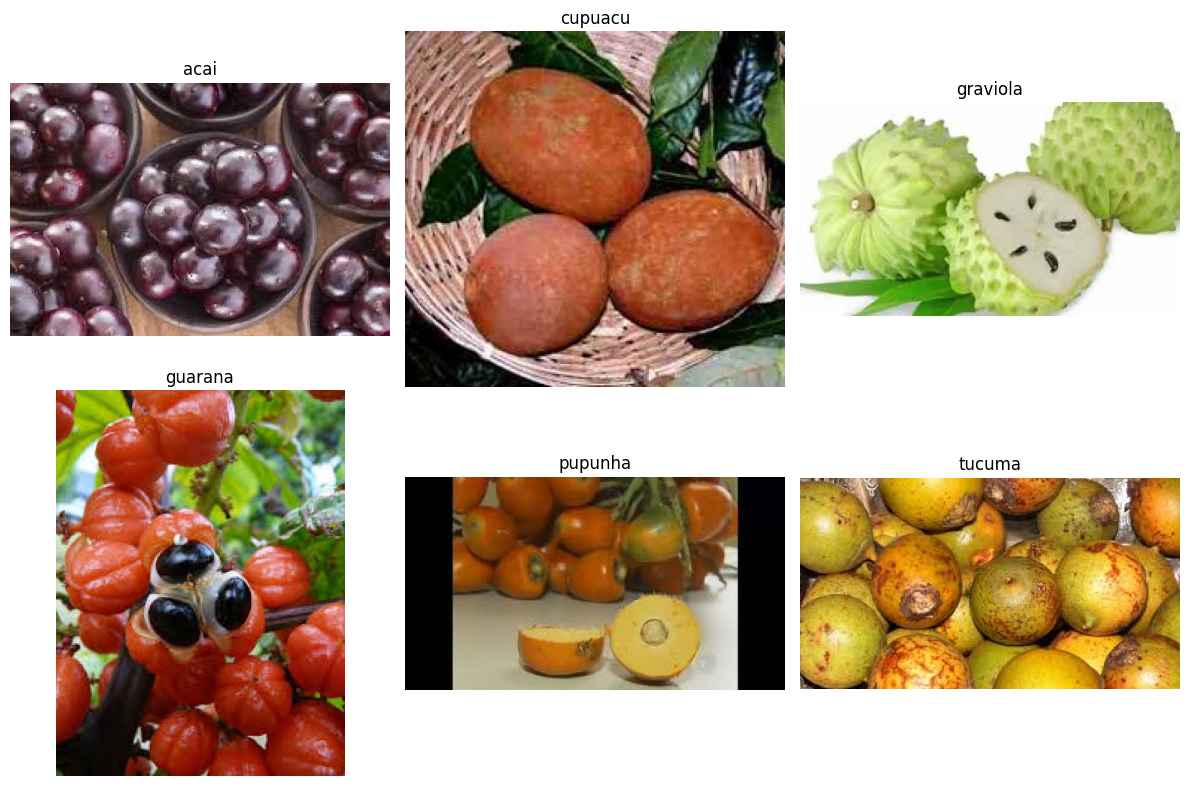

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Observation: Images vary in size, background, and lighting across classes.


In [ ]:
# Task 1.1 - Visualise one random image per class in a 2-row grid
class_dirs = sorted(os.listdir(train_dir))
num_classes = len(class_dirs)

cols = (num_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for i, cls in enumerate(class_dirs):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    img_path = os.path.join(cls_path, random.choice(images))  # random sample
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print(f"Classes found: {class_dirs}")
print("Observation: Images vary in size, background, and lighting across classes.")

In [ ]:
# Task 1.2 - Check for and remove corrupted images
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


## Task 2: Loading and Preprocessing Image Data

In [ ]:
# Hyperparameters
img_height      = 128
img_width       = 128
batch_size      = 16
validation_split = 0.2

# Normalise pixel values to [0, 1]
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test dataset (no split, full folder)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print(f"Number of classes: {num_classes}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Number of classes: 6


## Task 3: Build the CNN Model

In [ ]:
# CNN architecture
model = keras.Sequential([

    # Conv Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Conv Block 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # Flatten and fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),  # hidden layer 1
    layers.Dense(64,  activation='relu'),  # hidden layer 2

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile and Train the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Callbacks: save best model and stop early if no improvement
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.2434 - loss: 2.8955
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 359ms/step - accuracy: 0.2222 - loss: 2.8425 - val_accuracy: 0.1667 - val_loss: 2.0815
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.2056 - loss: 1.8918
Epoch 2: val_accuracy improved from 0.16667 to 0.72222, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - accuracy: 0.1944 - loss: 1.8216 - val_accuracy: 0.7222 - val_loss: 1.4702
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.5010 - loss: 1.5572
Epoch 3: val_accuracy improved from 0.72222 to 0.77778, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 321ms/step - accuracy: 0.4583 - loss: 1.4914 - val_accuracy: 0.7778 - val_loss: 1.3524
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.5493 - loss: 1.2648
Epoch 4: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 464ms/step - accuracy: 0.5694 - loss: 1.2394 - val_accuracy: 0.3889 - val_loss: 1.7036
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.6913 - loss: 1.0696
Epoch 5: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step - accuracy: 0.6806 - loss: 1.0750 - val_accuracy: 0.5556 - val_loss: 1.0994
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8073 - loss: 0.7627
Epoch 6: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 0.7917 - loss: 0.7716 - val_accuracy: 0.7778 - val_loss: 0.8507
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.8285 - loss: 0.558


Epoch 8: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step - accuracy: 0.9167 - loss: 0.3792 - val_accuracy: 0.8889 - val_loss: 0.5854
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9552 - loss: 0.2025
Epoch 9: val_accuracy improved from 0.88889 to 0.94444, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 0.9167 - loss: 0.2610 - val_accuracy: 0.9444 - val_loss: 0.3732
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9736 - loss: 0.1434
Epoch 10: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.9722 - loss: 0.1585 - val_accuracy: 0.7222 - val_loss: 0.6228
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 1.0000 - loss: 0.1022
Epoch 11: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step - accuracy: 1.0000 - loss: 0.0838 - val_accuracy: 0.8889 - val_loss: 0.5035
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 1.0000 - loss: 0.0604
Epoch 12: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 421ms/step - accuracy: 1.0000 - loss: 0.0572 - val_accuracy: 0.9444 - val_loss: 0.3305
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 1.0000 - loss

## Visualisation: Training & Validation Loss/Accuracy

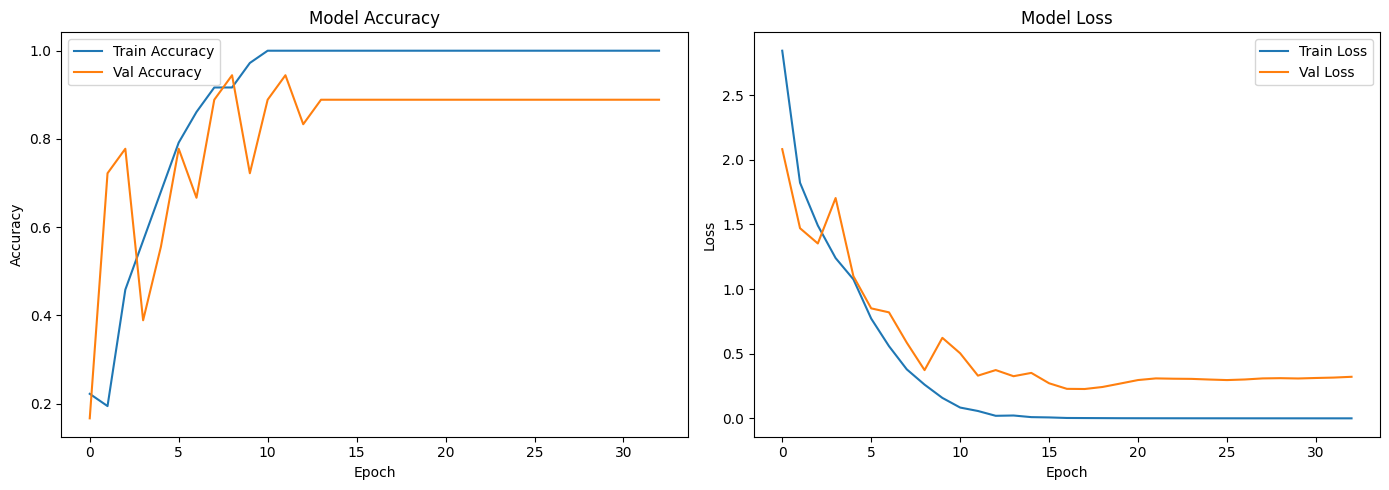

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6667 - loss: 1.1687
Test Loss:     1.1687
Test Accuracy: 0.6667


## Task 6: Save and Load the Model

In [ ]:
model.save('cnn_fruits_model.h5')
print("Model saved as cnn_fruits_model.h5")

# Load and re-evaluate to confirm it saved correctly
loaded_model = keras.models.load_model('cnn_fruits_model.h5')
loss, acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model - Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

Model saved as cnn_fruits_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6667 - loss: 1.1687
Loaded Model - Test Loss: 1.1687 | Test Accuracy: 0.6667


## Task 7: Predictions and Classification Report

In [ ]:
# Collect all true labels and predictions from test set
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_dirs))

              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.62      1.00      0.77         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.71      1.00      0.83         5
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.67        30
   macro avg       0.75      0.67      0.63        30
weighted avg       0.75      0.67      0.63        30

